# Exercícios - K-NN

## 1. No exemplo com dados artificiais de classificação, teste os valores $k=1$, $k=3$, $k=7$, $k=15$ e $k=31$. Como a região de decisão muda?

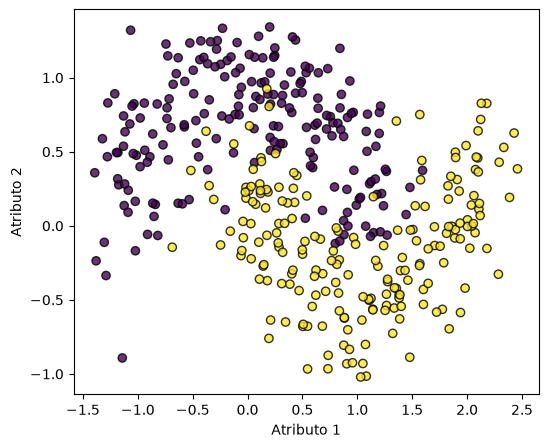

In [85]:
# Bibliotecas
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

# Define uma semente para os processos aleatórios.
# Isso permite reproduzir os mesmos resultados em diferentes execuções.
RANDOM_STATE = 42

# Define a semente do gerador de números aleatórios do NumPy.
np.random.seed(RANDOM_STATE)

# Gera um conjunto de dados artificial para classificação binária.
X, y = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', alpha=0.8)
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.grid(False)
plt.show()

Dividir os dados em treino e teste.

In [86]:
from sklearn.model_selection import train_test_split

# Divide o conjunto de dados em subconjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,stratify=y, random_state=RANDOM_STATE)

Padronizar usando Z-score

In [87]:
# Importa o StandardScaler, utilizado para padronizar os atributos.
from sklearn.preprocessing import StandardScaler

# Cria o padronizador e calcula, usando apenas o conjunto de treinamento, a média e o desvio-padrão de cada atributo.
scaler = StandardScaler().fit(X_train)

# Padroniza os atributos do conjunto de treinamento.
X_train = scaler.transform(X_train)

# Padroniza o conjunto de teste utilizando as mesmas médias
# e os mesmos desvios-padrão calculados no conjunto de treinamento.
X_test = scaler.transform(X_test)

Predição usando K-NN utilizando os diferentes K ($k=1$, $k=3$, $k=7$, $k=15$ e $k=31$)

K =  1  ->  Acurácia = 0.9125
K =  3  ->  Acurácia = 0.8750
K =  7  ->  Acurácia = 0.8875
K = 15  ->  Acurácia = 0.9125
K = 31  ->  Acurácia = 0.9250


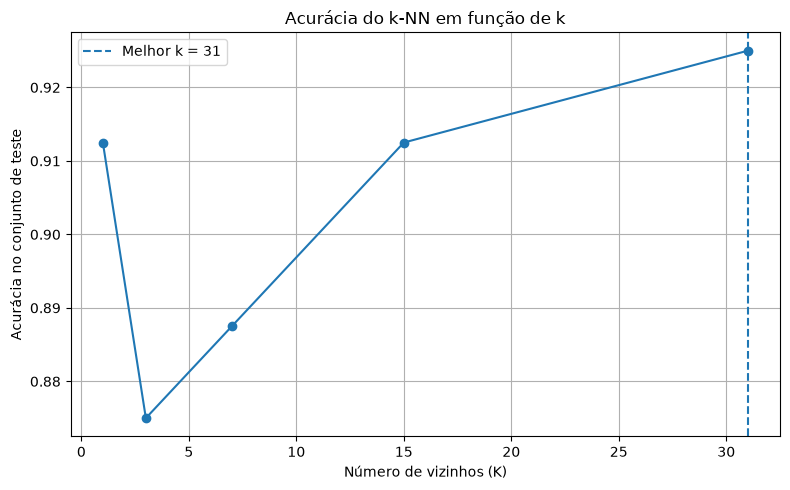

In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# valores de K a testar
k_values = [1, 3, 7, 15, 31]
accuracies = []

# treina e avalia um modelo para cada K
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f'K = {k:>2}  ->  Acurácia = {acc:.4f}')

# identifica o melhor K (maior acurácia)
best_idx = int(np.argmax(accuracies))
best_k = k_values[best_idx]

# gráfico de linha da acurácia por K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.axvline(x=best_k, color='tab:blue', linestyle='--',
            label=f'Melhor k = {best_k}')

plt.xlabel('Número de vizinhos (K)')
plt.ylabel('Acurácia no conjunto de teste')
plt.title('Acurácia do k-NN em função de k')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 2. Na base Iris, compare o desempenho do k-NN usando distância euclidiana e Manhattan.

In [89]:
# Bibliotecas
import numpy as np
import pandas as pd

# Define uma semente para os processos aleatórios.
# Isso permite reproduzir os mesmos resultados em diferentes execuções.
RANDOM_STATE = 42

# Define a semente do gerador de números aleatórios do NumPy.
np.random.seed(RANDOM_STATE)

# Gera um conjunto de dados artificial para classificação binária.
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)
data.head(10)

Matriz de atributos: Número de linhas: 150  colunas:  5


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [90]:
# Organizando os dados para usar como input no algoritmo
data = data.to_numpy()

nrow,ncol = data.shape

y = data[:,-1] # species
X = data[:,0:ncol-1] # features

In [91]:
# Separar em treino e teste
from sklearn.model_selection import train_test_split

p = 0.7 

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = RANDOM_STATE, stratify = y)

Padronização para evitar efeito da escala nas features

In [92]:
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k = 11 # numero de vizinhos

# ajusta o modelo k-vizinhos
model_euclidean = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
model_euclidean.fit(X_train,y_train)

model_manhattan = KNeighborsClassifier(n_neighbors=k, metric = 'manhattan')
model_manhattan.fit(X_train,y_train)

# faz a predição no conjunto de teste
y_pred_euclidean = model_euclidean.predict(X_test)
y_pred_manhattan = model_manhattan.predict(X_test)

score_euclidean = accuracy_score(y_pred_euclidean, y_test)
print(f'Accuracia para k={k}: {score_euclidean:.2f}')

score_manhattan = accuracy_score(y_pred_manhattan, y_test)
print(f'Acurácia para k={k}: {score_manhattan:.2f}')

Accuracia para k=11: 0.96
Acurácia para k=11: 0.93


O K-NN utilizando distância Euclidiana apresentou maior eficácia (i.e., 0,96) em comparação com o K-NN utilizando distância de Manhattan.

## 3. No exemplo de regressão artificial, aumente o ruído dos dados. O que acontece com o melhor valor de $k$?

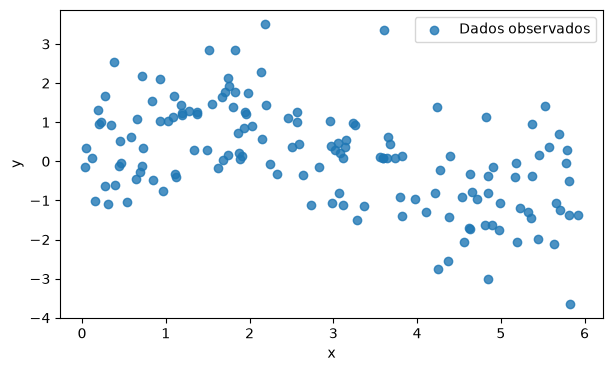

In [94]:
rng = np.random.RandomState(RANDOM_STATE)

# Gera 150 valores aleatórios entre 0 e 6.
# O formato (150, 1) indica:
# - 150 observações;
# - um único atributo para cada observação.
# np.sort organiza os valores em ordem crescente, facilitando posteriormente a visualização da curva estimada.
X_reg = np.sort(6 * rng.rand(150, 1),axis=0)

# Gera a variável resposta a partir da função seno.
# np.sin(X_reg) calcula o seno de cada valor de entrada.
# ravel() transforma o resultado de uma matriz (150, 1) em um vetor unidimensional com 150 elementos.
# O termo 0.25 * rng.randn(150) adiciona um erro aleatório com distribuição normal, média zero e desvio-padrão igual a 0.25.
y_reg = (np.sin(X_reg).ravel()+ 0.99 * rng.randn(150))

# Cria uma figura
plt.figure(figsize=(7, 4))

# Constrói um gráfico de dispersão com os dados gerados.
# alpha=0.8 define uma pequena transparência nos pontos.
# label define o texto que será apresentado na legenda.
plt.scatter(X_reg,y_reg,alpha=0.8,label='Dados observados')

# Define o rótulo do eixo horizontal.
plt.xlabel('x')

# Define o rótulo do eixo vertical.
plt.ylabel('y')

# Exibe a legenda do gráfico.
plt.legend()

# Remove as linhas de grade.
plt.grid(False)

# Exibe o gráfico.
plt.show()

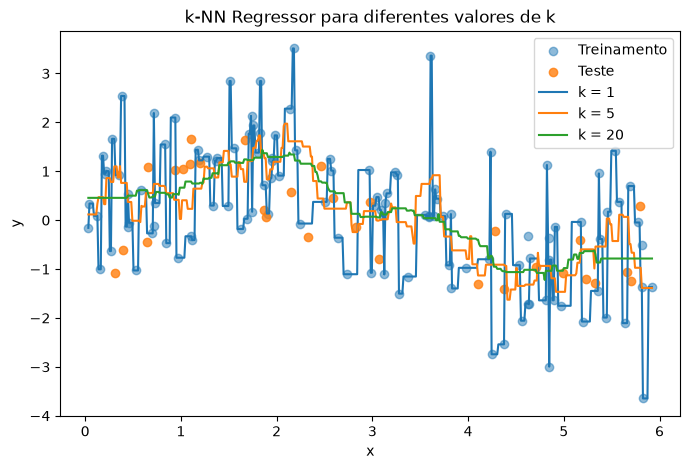

In [95]:
from sklearn.neighbors import KNeighborsRegressor 

# Divide os dados em conjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg,test_size=0.20,random_state=RANDOM_STATE)
# Cria uma grade com 500 valores igualmente espaçados entre o menor e o maior valor observado em X_reg.
x_grid = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)

# Cria uma figura
plt.figure(figsize=(8, 5))
# Exibe os dados utilizados no treinamento.
plt.scatter(X_train, y_train, alpha=0.5, label='Treinamento')
# Exibe os dados reservados para o teste.
plt.scatter(X_test, y_test, alpha=0.8, label='Teste')

# Ajusta modelos k-NN de regressão usando diferentes valores de k.
for k in [1, 5, 20]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_grid = model.predict(x_grid)
    plt.plot(x_grid, y_grid, label=f'k = {k}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('k-NN Regressor para diferentes valores de k')
plt.legend()
plt.grid(False)
plt.show()

Melhor k no conjunto de teste: 28
Menor RMSE: 0.7192309901221919


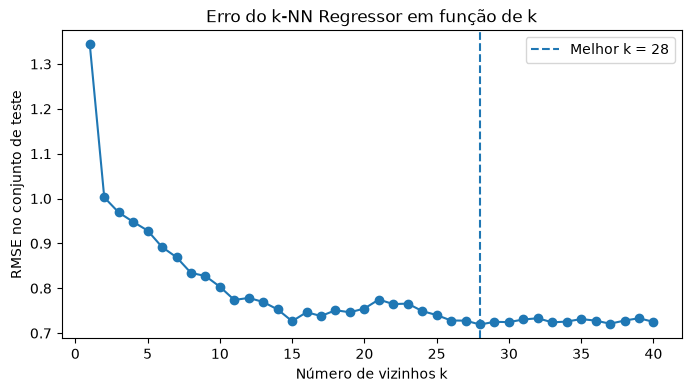

In [96]:
# Importa a função que calcula a raiz do erro quadrático médio.
from sklearn.metrics import root_mean_squared_error

# Define os valores de k que serão avaliados, de 1 até 40.
valores_k = range(1, 41)
rmse_teste = [] # Lista que armazenará o RMSE obtido para cada valor de k.

# Avalia o desempenho do regressor para diferentes números de vizinhos.
for k in valores_k:
    # Cria o modelo de regressão k-NN considerando k vizinhos.
    model = KNeighborsRegressor(n_neighbors=k)
    # Ajusta o modelo utilizando os dados de treinamento.
    model.fit(X_train, y_train)
    # Faz previsões para as observações do conjunto de teste.
    y_pred = model.predict(X_test)
    # Calcula a raiz do erro quadrático médio entre os valores reais e os valores previstos.
    rmse = root_mean_squared_error(y_test, y_pred)
    # Armazena o erro correspondente ao valor atual de k.
    rmse_teste.append(rmse)

# np.argmin retorna a posição do menor RMSE na lista.
indice_melhor = np.argmin(rmse_teste)

# Recupera o valor de k associado ao menor erro.
melhor_k = list(valores_k)[indice_melhor]

print('Melhor k no conjunto de teste:', melhor_k)
print('Menor RMSE:', min(rmse_teste))

plt.figure(figsize=(8, 4))
plt.plot(list(valores_k), rmse_teste, marker='o')
plt.axvline(melhor_k, linestyle='--', label=f'Melhor k = {melhor_k}')
plt.xlabel('Número de vizinhos k')
plt.ylabel('RMSE no conjunto de teste')
plt.title('Erro do k-NN Regressor em função de k')
plt.legend()
plt.grid(False)
plt.show()

Ao aumentar o ruído (de 0.25 para 0.99), o valor de `k` que produz a melhor predição também aumenta.

Isso porque um `k` maior faz a predição "olhar" mais vizinhos e assim suaviza o efeito do ruído, enquanto um `k` pequeno acaba se ajustando a pontos ruidosos individuais.

## 4. Substitua o `StandardScaler` por `MinMaxScaler` e compare os resultados.

In [97]:
# Bibliotecas
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define uma semente para os processos aleatórios.
# Isso permite reproduzir os mesmos resultados em diferentes execuções.
RANDOM_STATE = 42

# Define a semente do gerador de números aleatórios do NumPy.
np.random.seed(RANDOM_STATE)

# Gera um conjunto de dados artificial para classificação binária.
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN

# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Organizando em numpy
nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)
data.head(10)

# Organizando os dados para usar como input no algoritmo
data = data.to_numpy()

nrow,ncol = data.shape

y = data[:,-1] # species
X = data[:,0:ncol-1] # features

# Separar em treino e teste
p = 0.7 

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = RANDOM_STATE, stratify = y)

# Padronização
scaler = MinMaxScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

k = 11 # numero de vizinhos

# ajusta o modelo k-vizinhos
model_euclidean = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
model_euclidean.fit(X_train,y_train)

model_manhattan = KNeighborsClassifier(n_neighbors=k, metric = 'manhattan')
model_manhattan.fit(X_train,y_train)

# faz a predição no conjunto de teste
y_pred_euclidean = model_euclidean.predict(X_test)
y_pred_manhattan = model_manhattan.predict(X_test)

score_euclidean = accuracy_score(y_pred_euclidean, y_test)
print(f'Accuracia para k={k}: {score_euclidean:.2f}')

score_manhattan = accuracy_score(y_pred_manhattan, y_test)
print(f'Acurácia para k={k}: {score_manhattan:.2f}')

Matriz de atributos: Número de linhas: 150  colunas:  5
Accuracia para k=11: 0.93
Acurácia para k=11: 0.91


No dataset Iris, a substituição do `StandardScaler()` pelo `MinMaxScaler()` resultou em redução na acurácia do algoritmo k-NN, tanto com a distância Euclidiana quanto com a de Manhattan.